interactive(children=(FloatSlider(value=0.0, description='K', max=3.0, step=0.2), Output()), _dom_classes=('wi…

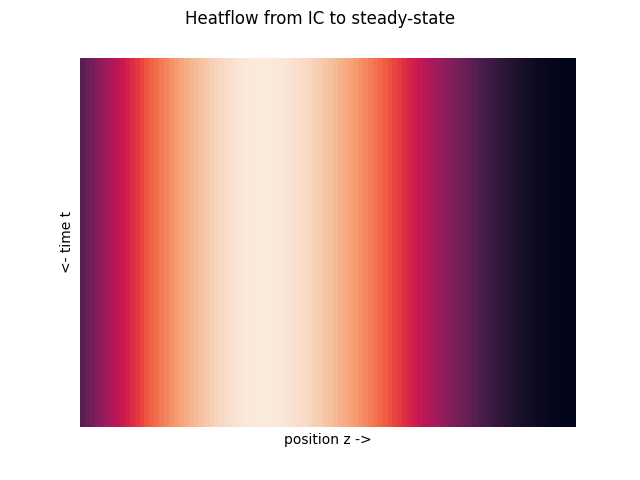

In [4]:
from ipywidgets import FloatSlider, IntSlider, interact
%matplotlib widget

import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from numpy import sin, exp, pi

L = 1

z = np.linspace(0,  L, 100)
t = np.linspace(0, 0.3, 100)

Z, T = np.meshgrid(z,t)

def soln(K):
    return(
     3*exp(-K*(  pi/2/L)**2*T)*sin(  pi*Z/2/L)
    +5*exp(-K*(3*pi/2/L)**2*T)*sin(3*pi*Z/2/L)
)

fig, ax = plt.subplots(1,1)
plt.suptitle('Heatflow from IC to steady-state')

@interact(
    K = FloatSlider(min=0, max=3, step=0.2)
)
def plot_heat(K):
    ax.clear()
    sns.heatmap(soln(K), ax=ax, xticklabels=False, yticklabels=False, cbar=False)
    ax.set_xlabel('position z ->')
    ax.set_ylabel('<- time t')


interactive(children=(IntSlider(value=10, description='N', max=500, min=1), FloatSlider(value=0.0, description…

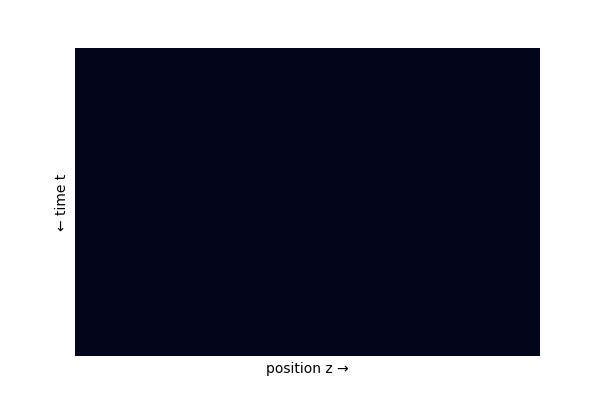

In [19]:
# Chatgpt version

from functools import lru_cache
import numpy as np
from numpy import pi, sin, exp

L = 1
K = 1

z = np.linspace(0,  L, 100)
t = np.linspace(0, 0.2, 100)
Z, T = np.meshgrid(z, t)

maxN = 500               # max slider value
n = np.arange(1, maxN+1) # [1,2,...,100]

sqrt_lbd = (2*n-1) * pi / (2*L)     # shape (N,)
SIN   = np.sin(sqrt_lbd[:,None] * z[None,:])      # (N, Z)
EXP = np.exp(-K * sqrt_lbd[:,None]**2 * t[None,:])  # (N, T)

# shape (N, T, Z)
BASIS = EXP[:,:,None] * SIN[:,None,:]


def soln(N, Phi, T1, T3):
    # Compute c_n ONCE per slider change (cheap, shape (N,))
    n = np.arange(1, N+1)
    c_n = (
        (-1)**n * 8 * L * Phi / (4*pi*pi*n*n - 4*pi*pi*n + pi*pi)
        - 4*T1/(2*pi*n - pi)
        + 4*T3/(2*pi*n - pi)
    )

    # Linear combination across basis modes
    u_modes = np.tensordot(c_n, BASIS[:N], axes=(0,0))

    return u_modes + T1 + Phi * Z

fig, ax = plt.subplots(figsize=(6,4))
cbar = None

@interact(
    N   = IntSlider(min=1, max=maxN, value=10),
    Phi = FloatSlider(min=-10, max=10, step=0.2),
    T1  = FloatSlider(min=-10, max=10, step=0.2),
    T3  = FloatSlider(min=-10, max=10, step=0.2),
)
def plot_heat(N, Phi, T1, T3):
    global cbar
    ax.clear()

    hm = sns.heatmap(soln(N, Phi, T1, T3),
                     ax=ax, cbar=False,
                     xticklabels=False, yticklabels=False)

    ax.set_xlabel("position z →")
    ax.set_ylabel("← time t")
    fig.canvas.draw_idle()


In [5]:
np.arange(1,1)

array([], dtype=int64)